In [1]:
import pyLIMA, os
import numpy as np
import matplotlib.pyplot as plt
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.models import FSPL_model,USBL_model,PSPL_model
from ipywidgets import interactive, HBox, VBox, Layout
from ipywidgets import (FloatSlider, FloatLogSlider, interactive_output, HBox, VBox, GridBox, Layout, Label)
from IPython.display import display
current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
import pyLIMA_plots

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [2]:
def get_param_order(m):
    for attr in ("model_dictionnary", "model_dictionary", "parameters_names", "parameter_names"):
        if hasattr(m, attr):
            val = getattr(m, attr)
            if isinstance(val, dict): 
                return list(val.keys())
            if isinstance(val, (list, tuple)): 
                return list(val)
    # fallback mínimo
    return ["t0", "u0", "tE", "piEN", "piEE", "fs_G", "fb_G"]

# --- Función de ploteo usando TODOS los valores de los widgets ---
def plot_from_widgets(**kw):
    # p arranca de la simulación base (garantiza completar faltantes)
    p = dict(sim_dict)

    # Actualizar con lo que venga de widgets
    p.update(kw)

    # Por compatibilidad: algunos modelos esperan nombres específicos; si algún
    # nombre del orden esperado no está en p, se toma de sim_dict (ya quedó arriba)
    params_list = [p[name] if name in p else sim_dict.get(name, None) for name in param_order]

    # Construir parámetros pyLIMA y magnificación
    py_params = model.compute_pyLIMA_parameters(params_list)
    A = model.model_magnification(model.event.telescopes[0], py_params)

    plt.figure(dpi=130)
    plt.plot(time_sim, 2.5 * np.log10(A), lw=1.2, label="USBL / DSPL (widgets)")
    plt.xlabel("Time (JD)")
    plt.ylabel(r"$\Delta$mag")
    plt.legend()
    plt.tight_layout()
    plt.show()

Create event, define telescope and choose a model

In [3]:
# ---- Event & telescope ----
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t0guess = 50
# u0guess = 0.01
time_sim = np.linspace(0, 100, 500)
lightcurve_sim = np.c_[time_sim, np.full_like(time_sim, 19.0), np.full_like(time_sim, 0.01)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)

# ---- Model base (USBL con doble fuente circular) ----
model = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['Circular', t0guess])
model.define_model_parameters()

In [4]:
np.random.seed(0)
params0 = simulator.simulate_microlensing_model_parameters(model)
param_order = get_param_order(model)
# Convertir vector simulado en dict
sim_dict = {name: val for name, val in zip(param_order, params0)}
# ------------------ Config de sliders ------------------
pi = np.pi
DEFAULTS = {
    't0': (t0guess - 100, t0guess + 100, 0.5),
    'u0': (-1.5, 1.5, 0.001),
    'tE': (1.0, 500.0, 0.5),
    'xi_para': (-1.0, 1.0, 1e-3),
    'xi_perp': (-1.0, 1.0, 1e-3),
    'xi_angular_velocity': (0.0, 10.0, 1e-3),
    'xi_phase': (0.0, 2*pi, 1e-3),
    'xi_inclination': (0.0, pi, 1e-3),
    'xi_mass_ratio': (0.0, 1.0, 1e-3),
    'q_flux_G': (0.0, 5.0, 1e-3),  # razón de flujos (S2/S1), ajustá si querés
}

# Para flujos absolutos, uso log-sliders (rango muy amplio)
LOG_SLIDERS = {
    'fsource_Simulation': (1e-2, 1e9),   # flux arbitrario (ajustá a tu escala)
    'fblend_Simulation': (1e-2, 1e9),
}

# Valores iniciales desde tu OrderedDict de referencia
user_init = {
    't0': 50,
    'u0': 0.010000000000000009,
    'tE': 40.0,
    'xi_para': 0.19588650039103989,
    'xi_perp': 0.23183138025051464,
    'xi_angular_velocity': 2.4092341172487513,
    'xi_phase': 4.974555126607196,
    'xi_inclination': 0.09077606762179125,
    'xi_mass_ratio': 0.5680445610939323,
    'q_flux_G': 0.14207211639577388,
    'fsource_Simulation': 4_087_735.6365653505,
    'fblend_Simulation': 2_166.3963887910973,
}

# Construir widgets dinámicamente
widgets = {}
for name, init_val in user_init.items():
    if name in LOG_SLIDERS:
        low, high = LOG_SLIDERS[name]
        # centrar el rango si init_val está fuera
        if not (low <= init_val <= high):
            low = min(low, max(init_val/100, 1e-9))
            high = max(high, init_val*100)
        w = FloatLogSlider(
            value=max(init_val, 1e-12),
            base=10, min=np.log10(low), max=np.log10(high), step=0.01,
            description=name, continuous_update=False, readout_format=".3g", layout=Layout(width='340px')
        )
    elif name in DEFAULTS:
        lo, hi, st = DEFAULTS[name]
        # expandir suave si el init cae fuera
        if init_val < lo: lo = init_val - abs(init_val)*0.2 - 1e-9
        if init_val > hi: hi = init_val + abs(init_val)*0.2 + 1e-9
        w = FloatSlider(
            value=init_val, min=lo, max=hi, step=st,
            description=name, continuous_update=False, readout_format=".6g", layout=Layout(width='340px')
        )
    else:
        # parámetro no configurado: slider genérico alrededor del valor
        span = max(1.0, abs(init_val)*0.5)
        w = FloatSlider(
            value=init_val, min=init_val - span, max=init_val + span, step=span/1000,
            description=name, continuous_update=False, readout_format=".6g", layout=Layout(width='340px')
        )
    widgets[name] = w

# Layout en grilla para que no se haga infinito hacia la derecha
controls = GridBox(
    list(widgets.values()),
    layout=Layout(grid_template_columns='repeat(2, 360px)', grid_gap='6px 10px')
)

# Conectar widgets -> salida
out = interactive_output(plot_from_widgets, {k: w for k, w in widgets.items()})
display(VBox([controls, out]))

In [5]:
import numpy as np
from astropy import units as u
from astropy import constants as C
def thetaE(Ds, Dl, Ml):
    """
    Ds (float): distance to the source in kpc
    Dl (float): distance to the lens in kpc
    Ml (float): mass of the lens in solar masses
    """
    dl = Dl*u.kpc
    ds = Ds*u.kpc
    M = Ml*u.M_sun
    k = 4*C.G/C.c**2
    pi_rel = 1/dl-1/ds
    arg = k*pi_rel*M
    thetaE = np.sqrt(arg)
    return thetaE.decompose()*u.rad
    
def generate_xiE(a_s, Ds, Dl, Ml, theta):
    """
    a_s (float): semi-major axis of the binary source system in AU
    Ds (float): distance to the source in kpc
    Dl (float): distance to the lens in kpc
    Ml (float): mass of the lens in solar masses
    theta (float): angle in radians
    """
    ds = Ds*u.kpc
    bot = thetaE(Ds, Dl, Ml)
    top = ((a_s*u.AU)/ds).decompose()*u.rad
    xiE = top/bot
    print(xiE)
    return xiE*np.cos(theta), xiE*np.sin(theta)  

def xi_mass_ratio(m1, m2): 
    """
    m1 (float): mass of primary source that is being magnified
    m2 (float): mass of companion
    """
    return ((m2*u.M_sun)/(m1*u.M_sun)).decompose()


def angular_velocity(P):
    """
    P (float): period in days
    return angular velocity in radians/day
    """
    return 2*np.pi/P

def tE(Ds, Dl, Ml, mu_rel):
    """
    mu_rel (float): relative proper motion in mas/year
    return tE in day
    """
    murel = mu_rel*u.mas/u.year
    return ((thetaE(Ds, Dl, Ml).to("mas"))/murel).to("day")

a_s = 2
Ds = 8
Dl = 4
Ml = 0.1
mu_rel = 5
theta = np.pi/2
P = 5
M1_source = 2
M2_source = 1
t0 = 50
u0 = 0.05
q_flux = 0.1
xiEE, xiEN = generate_xiE(a_s, Ds, Dl, Ml, theta)
print(np.sqrt(xiEE**2+ xiEN**2))
xi_q = xi_mass_ratio(2, 1)
omega = angular_velocity(P)
tE = tE(Ds, Dl, Ml, mu_rel).value
print(tE)
xi_inclination = 0
xi_phase = 0
ftotal=1000

0.7835559843595794
0.7835559843595794
23.307205055585673


In [6]:
import pandas as pd

data = [
    # Event 1
    {
        "Event": 1,
        "t_0": 50,
        "u_0": 0.05,
        "t_E": 12,
        "f_s": 1,
        "binary_flux_ratio": 0.1,
        "P": 0.4,
        "R": 0.01,
        "inclination": 0,
        "phi_0": 0
    },
    # Event 2
    {
        "Event": 2,
        "t_0": 50,
        "u_0": 0.5,
        "t_E": 35,
        "f_s": 1,
        "binary_flux_ratio": 0.1,
        "P": 60,
        "R": 0.2,
        "inclination": 0,
        "phi_0": 0
    },
    # Event 3
    {
        "Event": 3,
        "t_0": 50,
        "u_0": 0.2,
        "t_E": 30,
        "f_s": 1,
        "binary_flux_ratio": 0.1,
        "P": 25,
        "R": 0.1,
        "inclination": 0,
        "phi_0": 0
    },
    # Event 4
    {
        "Event": 4,
        "t_0": 50,
        "u_0": 0.1,
        "t_E": 25,
        "f_s": 1,
        "binary_flux_ratio": 0.1,
        "P": 7,
        "R": 0.05,
        "inclination": 0,
        "phi_0": 0
    },
    # Event 5
    {
        "Event": 5,
        "t_0": 50,
        "u_0": 0.3,
        "t_E": 15,
        "f_s": 1,
        "binary_flux_ratio": 0.1,
        "P": 1.5,
        "R": 0.02,
        "inclination": 0,
        "phi_0": 0
    }
]

df = pd.DataFrame(data)
# display(df)


pyLIMA parameters OrderedDict([('t0', 50.0), ('u0', 0.05), ('tE', 12.0), ('xi_para', 0.005), ('xi_perp', 0.0), ('xi_angular_velocity', 15.707963267948966), ('xi_phase', 0.0), ('xi_inclination', 0), ('xi_mass_ratio', 0.5), ('q_flux_G', 0.1), ('fsource_Simulation', 1), ('ftotal_Simulation', None)])


/tmp/ipykernel_169871/2105523307.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


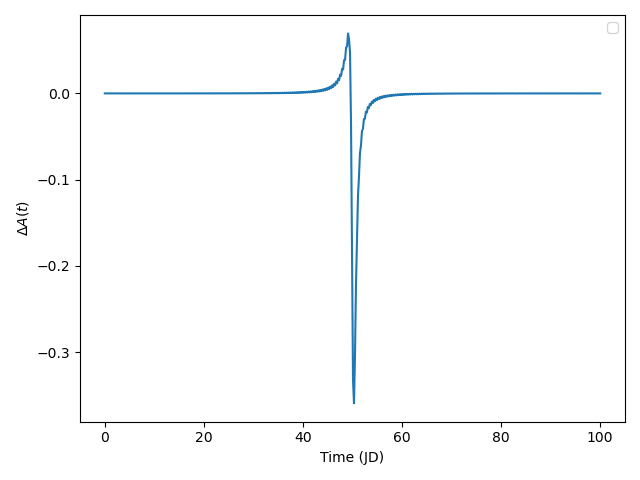

In [63]:
params_list = [0]*11
i=0
df_row = df.iloc[i]
params_list[0] = df_row['t_0'] 
params_list[1] = df_row['u_0'] 
params_list[2] = df_row['t_E'] 
theta = 0
params_list[3] = df_row['R']*np.cos(theta)/2
params_list[4] = df_row['R']*np.sin(theta)/2
params_list[5] = 2*np.pi/df_row['P']
params_list[6] = 0*np.pi/2
params_list[7] = 0
params_list[8] = 0.5
params_list[9] = 0.1
params_list[10] = 1
# params_list[11] = 10000000


plt.close("all")
py_params = model.compute_pyLIMA_parameters(params_list)

print("pyLIMA parameters", py_params)
A = model.model_magnification(model.event.telescopes[0], py_params)
%matplotlib widget
plt.figure(dpi=120)
plt.plot(time_sim, A, label="DSPL")
A_som = np.load("/home/anibal/Downloads/Events_binary-20251017T153954Z-1-001/Events_binary/Event_0/A.npy")
T_som =np.load("/home/anibal/Downloads/Events_binary-20251017T153954Z-1-001/Events_binary/Event_0/time_sim.npy")
# plt.plot(T_som,A_som)
# plt.xlabel("Time (JD)")
# plt.ylabel(r"$A(t)$")
# plt.legend()
# plt.tight_layout()
# plt.show()
plt.close("all")
plt.plot(T_som,A_som-A)
# np.savez(f"/home/anibal/Downloads/Events_binary-20251017T153954Z-1-001/Events_binary/Event_0/Event_{i}.npz", time_sim=time_sim, A=A)
plt.xlabel("Time (JD)")
plt.ylabel(r"$\Delta A(t)$")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# list(py_params.values())

Text(0, 0.5, ' y trajectory ')

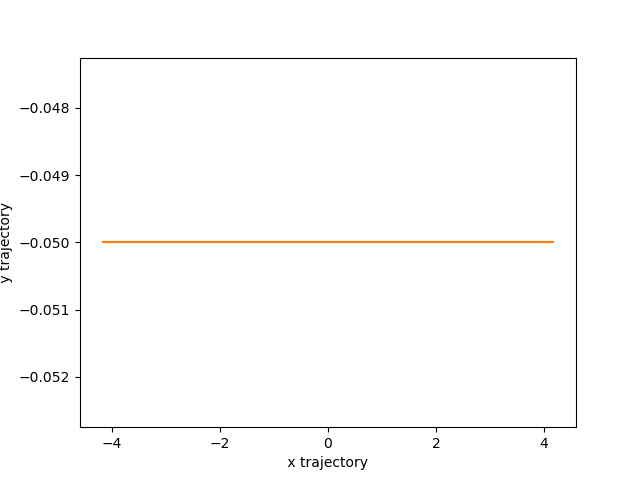

In [65]:
plt.close("all")
(source1_trajectory_x, source1_trajectory_y,source2_trajectory_x, source2_trajectory_y, dseparation, dalpha) = model.sources_trajectory(model.event.telescopes[0], py_params, data_type='photometry')
plt.plot(source1_trajectory_x,source1_trajectory_y)
plt.plot(source2_trajectory_x,source2_trajectory_y)
plt.xlabel(" x trajectory ")
plt.ylabel(" y trajectory ")

(<Figure size 700x700 with 1 Axes>, None)

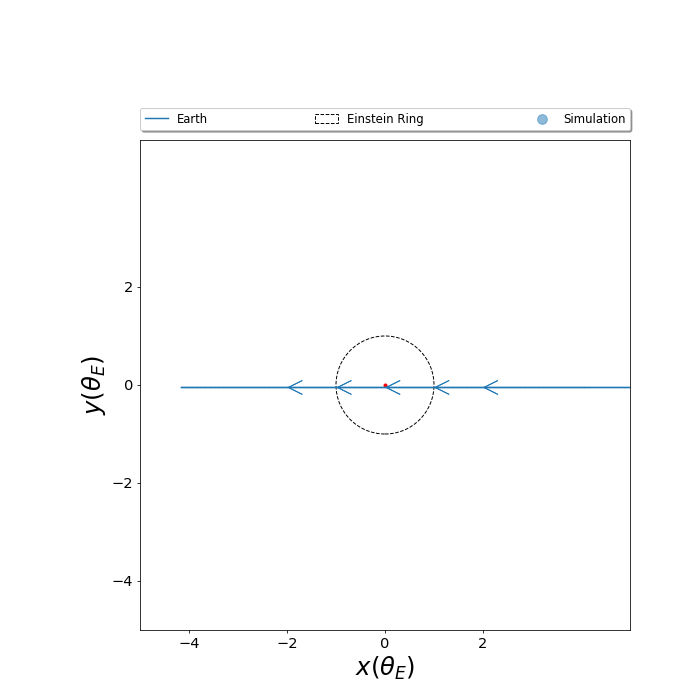

In [66]:
%matplotlib ipympl

pyLIMA_plots.plot_geometry(model, params_list)

In [13]:
import numpy as np

# -------------------------
# INPUTS DEL CASO
# -------------------------

rhatE_au = 5.0                     # Einstein radius en el plano de la FUENTE
v_rel_kms = 50.0                  # velocidad relativa lente–fuente
M_NS = 1.4                        # masas en M⊙
M_star = 2.0
a_total_au = 2.0                  # separación total
DS_pc = 8000                      # ejemplo DS
DL_pc = 4000                      # ejemplo DL

# -------------------------
# 1) Semiejes baricéntricos
# -------------------------

M_tot = M_NS + M_star
q = M_NS / M_star                 # razón de masas (útil para pyLIMA)

a_NS_au = a_total_au * (M_star / M_tot)
a_star_au = a_total_au * (M_NS / M_tot)

print(f"NS orbit radius a_NS = {a_NS_au:.3f} AU")
print(f"Luminous star orbit radius a_S = {a_star_au:.3f} AU")

# -------------------------
# 2) Periodo orbital de la FUENTE (Kepler)
# -------------------------

P_xi_yr = np.sqrt(a_total_au**3 / M_tot)
P_xi_days = P_xi_yr * 365.25
omega_xi = 2*np.pi / P_xi_days     # rad/día

print(f"Orbital period P_xi = {P_xi_yr:.3f} yr")
print(f"Angular velocity ω_xi = {omega_xi:.6f} rad/day")

# -------------------------
# 3) r_E verdadero (plano de la lente)
# -------------------------

DS_km = DS_pc * 3.086e13
DL_km = DL_pc * 3.086e13

# rhat_E = r_E * (DS/DL)
rE_au = rhatE_au * (DL_km / DS_km)

# -------------------------
# 4) Einstein time t_E
# -------------------------

v_rel_au_per_day = (v_rel_kms * 1e5) * (1/1.496e13) * 86400
tE_days = rE_au / v_rel_au_per_day

print(f"Einstein radius in lens plane r_E = {rE_au:.4f} AU")
print(f"Einstein time t_E = {tE_days:.3f} days")

# -------------------------
# 5) Xallarap amplitude ξ_E = a_S / rhat_E
# -------------------------

xiE = a_star_au / rhatE_au

# Componentes (alineemos xiE con eje x para simplicidad)
xiE_para = xiE
xiE_perp  = 0.0

print(f"xiE amplitude = {xiE:.6f}")
print(f"xiE_para = {xiE_para:.6f}, xiE_perp = {xiE_perp:.6f}")

# -------------------------
# 6) Parámetros listos para pyLIMA
# -------------------------

xi_phase = 0.0                    # Caso: fase = 0
xi_inclination = np.deg2rad(90)  # Face-on = 90°
xi_mass_ratio = q

print("\nPyLIMA inputs:")
print(f"xi_angular_velocity = {omega_xi}")
print(f"xi_phase = {xi_phase}")
print(f"xi_inclination = {xi_inclination} rad")
print(f"xi_mass_ratio = {xi_mass_ratio}")
print(f"xi_para = {xiE_para}")
print(f"xi_perp = {xiE_perp}")


NS orbit radius a_NS = 1.176 AU
Luminous star orbit radius a_S = 0.824 AU
Orbital period P_xi = 1.534 yr
Angular velocity ω_xi = 0.011215 rad/day
Einstein radius in lens plane r_E = 2.5000 AU
Einstein time t_E = 86.574 days
xiE amplitude = 0.164706
xiE_para = 0.164706, xiE_perp = 0.000000

PyLIMA inputs:
xi_angular_velocity = 0.011214608286625353
xi_phase = 0.0
xi_inclination = 1.5707963267948966 rad
xi_mass_ratio = 0.7
xi_para = 0.16470588235294117
xi_perp = 0.0


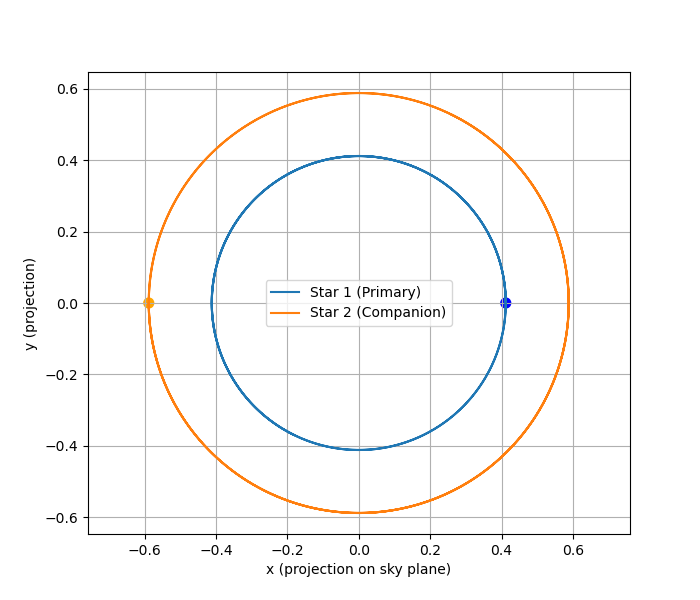

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARÁMETROS DEL MODELO ---
# P = 10.0                          # periodo orbital
omega = omega_xi #2*np.pi / P               # velocidad angular
t0_xi = 0.0                       # época de fase
phi_xi = 0#np.pi/3                  # fase inicial
incl = xi_inclination             # inclinación
q = 0.7                           # razón de masas M2/M1
mass1 = q/(1+q)                   # distancia baricéntrica de la fuente iluminante
mass2 = 1/(1+q)                   # distancia baricéntrica del compañero

# --- TIEMPOS ---
t = np.linspace(0, 300*P, 2000)


def circular_xallarap(time, t0_xi, xi_angular_velocity, xi_phase,
                      xi_inclination):


    angular_velocity = xi_angular_velocity

    omega = angular_velocity*(time-t0_xi)+xi_phase

    separation_1 = np.cos(omega)#-np.cos(xi_phase)
    separation_2 = np.sin(xi_inclination)*(np.sin(omega))#np.sin(xi_phase))

    return np.array([separation_1, separation_2])

Sx, Sy = circular_xallarap(t, t0_xi, omega, phi_xi, incl)

x1 = Sx * mass1
y1 = Sy * mass1


x2 = -Sx * mass2
y2 = -Sy * mass2

# --- GRAFICAR ---
plt.figure(figsize=(7,6))
plt.plot(x1, y1, label="Star 1 (Primary)")
plt.plot(x2, y2, label="Star 2 (Companion)")

plt.scatter([x1[0], x2[0]], [y1[0], y2[0]], c=['blue','orange'], s=50)

plt.xlabel("x (projection on sky plane)")
plt.ylabel("y (projection)")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()


pyLIMA parameters OrderedDict([('t0', 200), ('u0', 0.3), ('tE', 86.57407407407408), ('xi_para', <Quantity 4.79789664e-17>), ('xi_perp', <Quantity 0.78355598>), ('xi_angular_velocity', 0.011214608286625353), ('xi_phase', 0.0), ('xi_inclination', 0), ('xi_mass_ratio', 0.7), ('q_flux_G', 10), ('fsource_Simulation', 10), ('ftotal_Simulation', None)])


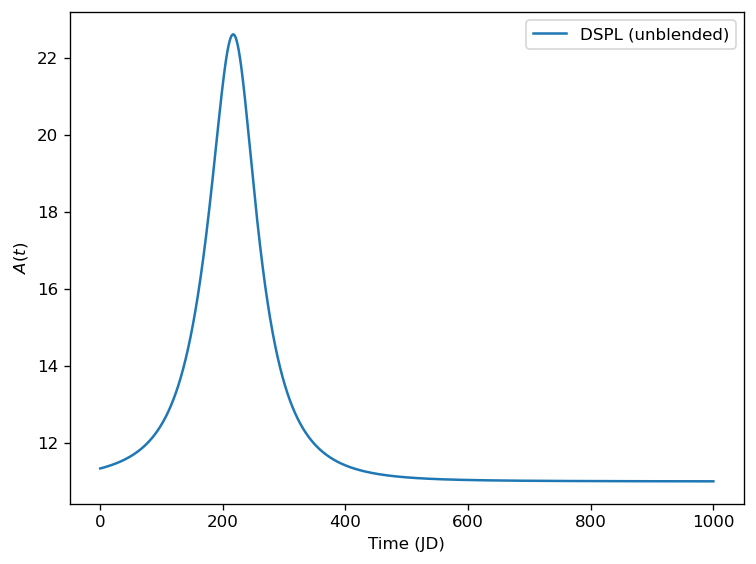

In [15]:
params_list = [0]*11
i=4
df_row = df.iloc[i]
params_list[0] = 200 
params_list[1] = df_row['u_0'] 
params_list[2] = tE_days
params_list[3] = xiEE 
params_list[4] = xiEN
params_list[5] = omega_xi
params_list[6] = df_row['phi_0']
lambda_xi = 0
params_list[7] = lambda_xi
params_list[8] = q
params_list[9] = 10
params_list[10] = 10
plt.close("all")
%matplotlib inline
py_params = model.compute_pyLIMA_parameters(params_list)

print("pyLIMA parameters", py_params)
A = model.model_magnification(model.event.telescopes[0], py_params)

plt.figure(dpi=120)
plt.plot(time_sim, A, label="DSPL (unblended)")

np.savez(f"/home/anibal/comparision_binary_sources/Event_{i}.npz", time_sim=time_sim, A=A)
plt.xlabel("Time (JD)")
plt.ylabel(r"$A(t)$")
plt.legend()
plt.tight_layout()
plt.show()

(<Figure size 700x700 with 1 Axes>, None)

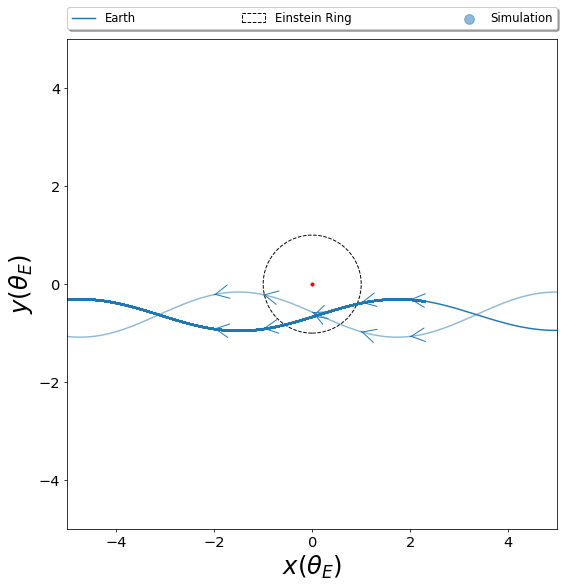

In [16]:
pyLIMA_plots.plot_geometry(model,params_list)